##Analysis Results:
1. Most crimes in the dataset are Fraud crimes
2. Uniform distribution across gender and race
3. Uniform distribution across city and state
4. Most violent crimes commited have been using a firearm
5. North and South districts have moderately higher entries
6. There is a drop in number of cases in 2023
7. There are comparatively more crimes committed between the hours 12:00 AM and 5:00 AM


In [791]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [792]:
df = pd.read_csv("/content/crime_incidents_messy.csv")

In [793]:
df.head()

,incident_id,crime_type,district,city,state,address,latitude,longitude,incident_datetime,officer_id,...,victim_gender,victim_phone,weapon_used,severity,case_status,resolution,num_arrests,property_loss_usd,reported_online,notes
0,INC001115,asslt,Sou,Maplewood,GA,2830 Cedar Lane,170.284100,-77.500710,2024-04-16 08:45:03,OFF0078,...,Unknown,6223265920,Firearm,2,Open,No Arrest,NaN,NaN,True,Incident at 2830 Cedar Lane. Officer responded...
1,INC004706,burglary,southeast,Maplewood,OH,2361 Park Rd,29.422717,-77.167016,2022-01-11 22:03:29,OFF0059,...,NaN,241-973-4826,Firearm,3,NaN,NaN,2.0,44839.49,yes,Incident at 2361 Park Rd. Officer responded at...
2,INC002249,Homocide,Southwest,Lakewood,AZ,1067 Main St,39.411460,-98.615298,2022-04-14 11:39:24,OFF0088,...,Other,244-584-7696,KNIFE,1,CLOSED,warning,2.0,15963.38,YES,Incident at 1067 Main St. Officer responded at...
3,INC000021,Property Damage,Cen,Springfield,AZ,4713 Washington Ave,28.633439,-99.030051,2020-12-09 15:14:24,OFF0077,...,NaN,5021227484,hands,Low,Resolved,NaN,5.0,48680.14,False,Incident at 4713 Washington Ave. Officer respo...
4,INC000488,Domestc Violence,North,Lakewood,PA,1371 River Rd,34.217850,-121.614731,2021-07-24 20:08:13,OFF0083,...,M,9698766873,Unarmed,MEDIUM,Closed,Warning Issued,2.0,23513.01,YES,NaN


In [794]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   incident_id         5250 non-null   object 
 1   crime_type          5250 non-null   object 
 2   district            5250 non-null   object 
 3   city                5250 non-null   object 
 4   state               5250 non-null   object 
 5   address             5250 non-null   object 
 6   latitude            4992 non-null   float64
 7   longitude           4961 non-null   float64
 8   incident_datetime   4910 non-null   object 
 9   officer_id          5250 non-null   object 
 10  officer_first_name  5250 non-null   object 
 11  officer_last_name   5250 non-null   object 
 12  badge_number        4938 non-null   float64
 13  suspect_id          4440 non-null   object 
 14  suspect_first_name  4440 non-null   object 
 15  suspect_last_name   4440 non-null   object 
 16  suspec

In [795]:
df["incident_id"].nunique()

5050

In [796]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [797]:
df.isna().sum()

,0
incident_id,0
crime_type,0
district,0
city,0
state,0
address,0
latitude,258
longitude,289
incident_datetime,340
officer_id,0


In [798]:
pd.set_option("display.max_rows",None)
df["crime_type"].value_counts(ascending=True)

,count
crime_type,
drug offense,1
Assault & Battery,1
Asslt,1
drunk driving,1
Sexual Assualt,1
burglary,1
abduction,1
narcotics,1
duii,1


In [799]:

crime_type_map = {
    "drug offense": "Drug Offense",
    "drug offence": "Drug Offense",
    "drugs": "Drug Offense",
    "narcotics": "Drug Offense",

    "asslt": "Assault",
    "assault": "Assault",
    "assault & battery": "Assault & Battery",

    "battery": "Battery",

    "sexual assualt": "Sexual Assault",
    "sexual assault": "Sexual Assault",
    "sex assault": "Sexual Assault",
    "sa": "Sexual Assault",

    "dui": "DUI",
    "d.u.i.": "DUI",
    "dwi": "DUI",
    "duii": "DUI",
    "drunk driving": "DUI",

    "burglary": "Burglary",
    "burglry": "Burglary",

    "abduction": "Abduction",
    "kidnaping": "Abduction",
    "kidnapping": "Abduction",

    "theft": "Theft",
    "theft/larceny": "Theft",
    "larceny": "Theft",
    "stealing": "Theft",

    "robbery": "Robbery",
    "robbry": "Robbery",
    "roberry": "Robbery",
    "armed robbery": "Armed Robbery",

    "trespass": "Trespassing",
    "trespassing": "Trespassing",
    "tresspassing": "Trespassing",

    "vandalism": "Vandalism",
    "vandlism": "Vandalism",

    "fraud": "Fraud",
    "fraudulent activity": "Fraud",
    "online fraud": "Fraud",
    "scam": "Fraud",
    "deception": "Fraud",

    "dv": "Domestic Violence",
    "domestic violence": "Domestic Violence",
    "dom. violence": "Domestic Violence",
    "domestc violence": "Domestic Violence",

    "cyber crime": "Cybercrime",
    "cybercrime": "Cybercrime",
    "hacking": "Cybercrime",

    "property damage": "Property Damage",
    "graffiti": "Property Damage",

    "homicide": "Homicide",
    "homocide": "Homicide",
    "murder": "Homicide",
    "manslaughter": "Homicide",

    "arson": "Arson",
    "arsen": "Arson",
    "fire setting": "Arson",

    "b&e": "Breaking & Entering",
    "breaking & entering": "Breaking & Entering",
}

df["_crime_type_normalized"] = (
    df["crime_type"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
)

unmatched = df.loc[
    ~df["_crime_type_normalized"].isin(crime_type_map),
    "_crime_type_normalized"
].dropna().unique()

print("Unmatched values:", unmatched)

df["crime_type"] = df["_crime_type_normalized"].map(crime_type_map)

df.drop(columns="_crime_type_normalized", inplace=True)

Unmatched values: <StringArray>
[]
Length: 0, dtype: string


In [800]:
df["crime_type"].value_counts()

,count
crime_type,
Fraud,457
Arson,369
DUI,369
Drug Offense,362
Homicide,357
Theft,348
Abduction,343
Sexual Assault,342
Trespassing,340


<Axes: ylabel='crime_type'>

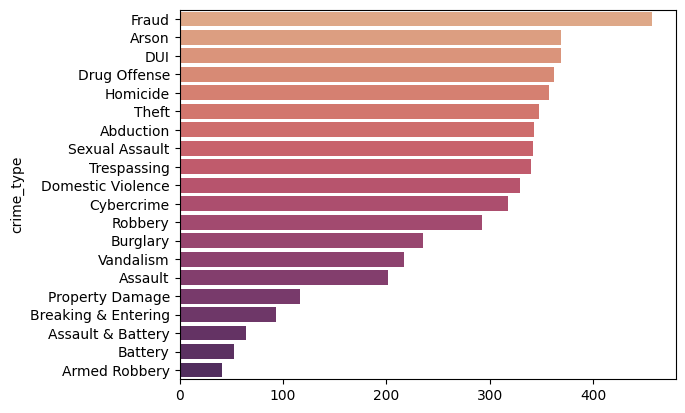

In [801]:
counts = df["crime_type"].value_counts()

sns.barplot(
    x=counts.values,
    y=counts.index,
    hue = counts.index,
    palette="flare"
)

In [802]:
df["weapon_used"].value_counts()

,count
weapon_used,
Hands/Feet,368
Unarmed,361
Rifle,346
Knife,339
KNIFE,335
Blunt Object,334
blunt object,327
Gun,318
hands,317


In [803]:
weapon_used_map = {
    "hands/feet": "Unarmed",
    "hands": "Unarmed",

    "unarmed": "Unarmed",

    "rifle": "Firearm",

    "knife": "Knife",

    "blunt object": "Blunt Object",

    "gun": "Firearm",
    "firearm": "Firearm",

    "pistol": "Firearm",

    "bat": "Blunt Object",
}

normalized = (
    df["weapon_used"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
)

df["weapon_used"] = normalized.map(weapon_used_map)

unmatched = normalized[
    ~normalized.isin(weapon_used_map)
].dropna().unique()

print("Unmatched values:", unmatched)

Unmatched values: <StringArray>
[]
Length: 0, dtype: string


<Axes: xlabel='weapon_used', ylabel='count'>

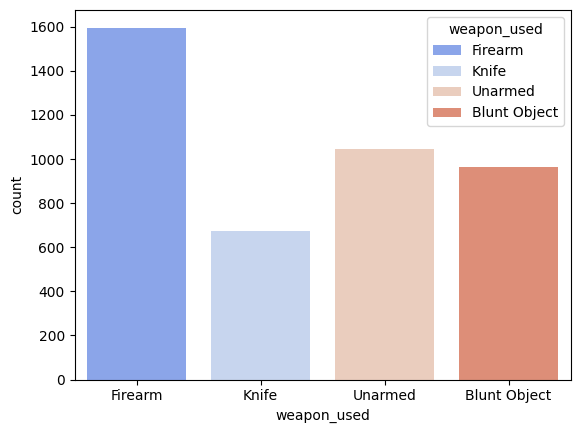

In [804]:
sns.countplot(data=df,x="weapon_used",hue="weapon_used",palette="coolwarm")

In [805]:
df["weapon_used"].value_counts()

,count
weapon_used,
Firearm,1596
Unarmed,1046
Blunt Object,964
Knife,674


In [806]:
suspect_race_map = {
    "black": "Black",
    "hispanic": "Hispanic",
    "asian": "Asian",
    "unknown": "Unknown",
    "white": "White",
    "other": "Other",
}

normalized = (
    df["suspect_race"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
)

df["suspect_race"] = normalized.map(suspect_race_map)

unmatched = normalized[
    ~normalized.isin(suspect_race_map)
].dropna().unique()

print("Unmatched values:", unmatched)

Unmatched values: <StringArray>
[]
Length: 0, dtype: string


In [807]:
df["suspect_race"].value_counts()

,count
suspect_race,
Black,780
Hispanic,745
White,712
Asian,706
Unknown,367
Other,339


<Axes: xlabel='suspect_race', ylabel='count'>

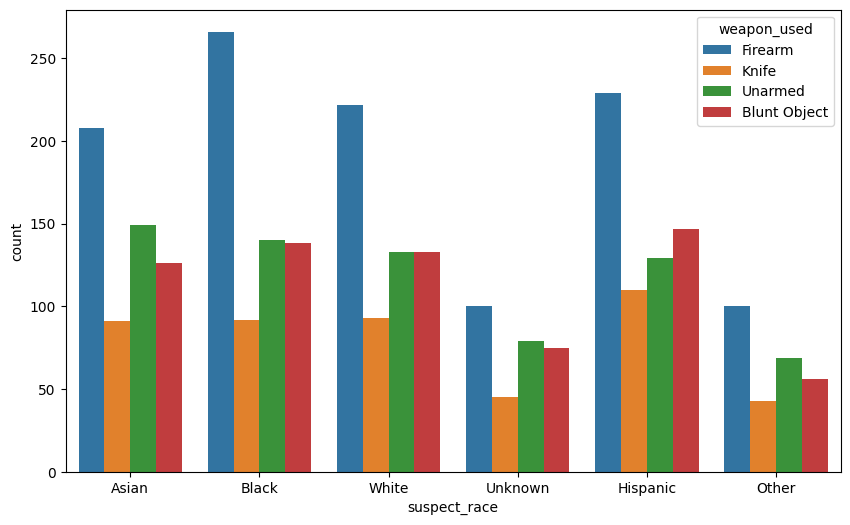

In [808]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="suspect_race",hue="weapon_used",palette="tab10")

<Axes: xlabel='suspect_race', ylabel='count'>

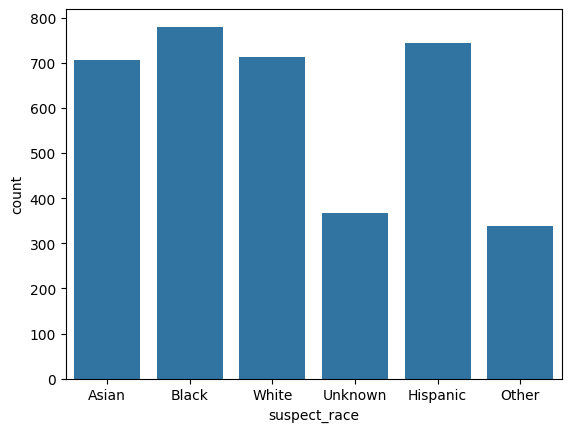

In [809]:
sns.countplot(data=df,x="suspect_race")

In [810]:
df.duplicated().sum()

np.int64(200)

In [811]:
df.drop_duplicates(inplace=True)

In [812]:
df.duplicated().sum()

np.int64(0)

In [813]:
df.shape

(5050, 33)

In [814]:
pd.set_option("display.max_rows",50)
df.shape

(5050, 33)

In [815]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5050 entries, 0 to 5249
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   incident_id         5050 non-null   object 
 1   crime_type          5050 non-null   object 
 2   district            5050 non-null   object 
 3   city                5050 non-null   object 
 4   state               5050 non-null   object 
 5   address             5050 non-null   object 
 6   latitude            4799 non-null   float64
 7   longitude           4772 non-null   float64
 8   incident_datetime   4721 non-null   object 
 9   officer_id          5050 non-null   object 
 10  officer_first_name  5050 non-null   object 
 11  officer_last_name   5050 non-null   object 
 12  badge_number        4749 non-null   float64
 13  suspect_id          4275 non-null   object 
 14  suspect_first_name  4275 non-null   object 
 15  suspect_last_name   4275 non-null   object 
 16  suspect_age

In [816]:
df = df[
    (
        df["victim_age"].between(16, 85, inclusive="both") |
        df["victim_age"].isna()
    )
    &
    (
        df["suspect_age"].between(16, 85, inclusive="both") |
        df["suspect_age"].isna()
    )
]
df.shape

(3792, 33)

,victim_age
count,3285.000000
mean,50.557686
std,20.209864
min,16.000000
25%,33.000000
50%,50.000000
75%,68.000000
max,85.000000


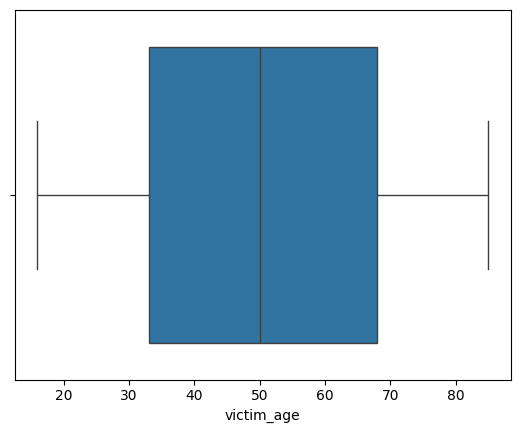

In [898]:
sns.boxplot(data=df,x="victim_age")
df["victim_age"].describe()

,suspect_age
count,2941.000000
mean,45.769806
std,17.202863
min,16.000000
25%,31.000000
50%,46.000000
75%,60.000000
max,75.000000


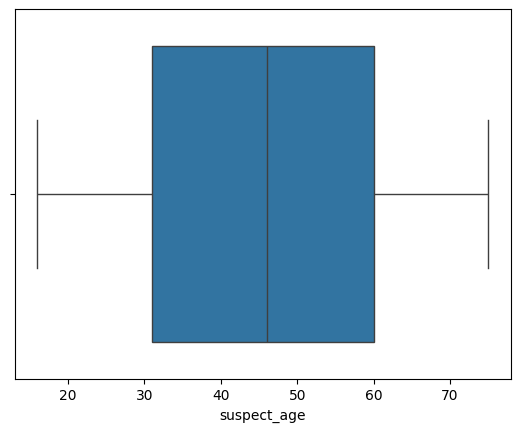

In [897]:
sns.boxplot(data=df,x="suspect_age")
df["suspect_age"].describe()

In [819]:
df["reported_online"].value_counts()

,count
reported_online,
0,403
False,363
1,351
Yes,349
No,348
True,335
no,326
yes,324
YES,321


In [820]:
df["severity"].value_counts()

,count
severity,
4,278
MEDIUM,268
high,267
3,263
Medium,260
1,255
Med,253
low,253
Low,245


In [821]:
df["victim_gender"].value_counts()

,count
victim_gender,
M,274
Male,268
female,265
Unknown,264
m,262
Other,258
male,253
MALE,244
Female,239


In [822]:
df["badge_number"].value_counts()

,count
badge_number,
8124.0,5
5137.0,4
8296.0,4
8638.0,4
5956.0,4
...,...
7567.0,1
9450.0,1
9072.0,1


In [823]:
df["officer_id"].isna().sum()

np.int64(0)

In [824]:
df["officer_id"].describe()

,officer_id
count,3792
unique,150
top,OFF0015
freq,40


In [825]:
df.shape

(3792, 33)

In [826]:
df.isna().sum().sort_values(ascending=True)

,0
incident_id,0
crime_type,0
district,0
city,0
state,0
address,0
officer_first_name,0
officer_id,0
officer_last_name,0
latitude,190


In [827]:
df["suspect_gender"].value_counts()

,count
suspect_gender,
F,262
female,243
male,239
m,236
Unknown,230
M,229
Other,229
Female,228
MALE,221


In [828]:
df["case_status"].value_counts()

,count
case_status,
closed,286
Investgation,286
Pending,276
Under Investigation,275
Open,274
open,269
OPEN,267
CLOSED,265
Closed,265


In [829]:
df["resolution"].value_counts()

,count
resolution,
Warning Issued,376
warning,361
No Arrest,348
arrest made,347
Arrest Made,346
Arres Made,336
Dismissed,330
Case Dismissed,325
NO ARREST,323


In [830]:
df["incident_datetime"].value_counts()

,count
incident_datetime,
2022-02-10 21:44:25,2
2022-10-20 03:47:10,2
2021-08-09 07:03:29,2
2024-08-27 07:54:09,2
2022-09-17 06:35:49,2
...,...
2024-10-22 10:42:04,1
2021-09-24 07:50:28,1
2021-05-28 20:47:34,1


In [831]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3792 entries, 0 to 5249
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   incident_id         3792 non-null   object 
 1   crime_type          3792 non-null   object 
 2   district            3792 non-null   object 
 3   city                3792 non-null   object 
 4   state               3792 non-null   object 
 5   address             3792 non-null   object 
 6   latitude            3602 non-null   float64
 7   longitude           3587 non-null   float64
 8   incident_datetime   3541 non-null   object 
 9   officer_id          3792 non-null   object 
 10  officer_first_name  3792 non-null   object 
 11  officer_last_name   3792 non-null   object 
 12  badge_number        3571 non-null   float64
 13  suspect_id          3172 non-null   object 
 14  suspect_first_name  3172 non-null   object 
 15  suspect_last_name   3172 non-null   object 
 16  suspect_age

In [832]:
reported_map = {
    "1": True,
    "true": True,
    "yes": True,
    "0": False,
    "false": False,
    "no": False
}

df["reported_online"] = (
    df["reported_online"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(reported_map)
)


<Axes: xlabel='reported_online', ylabel='count'>

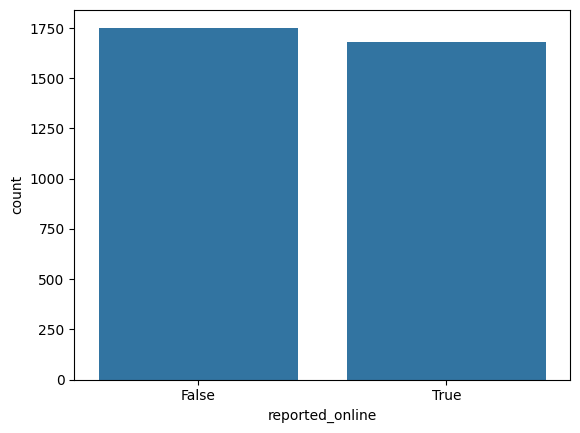

In [833]:
sns.countplot(data=df,x="reported_online")

In [834]:
severity_map = {
    "1": "LOW",
    "low": "LOW",

    "2": "MEDIUM",
    "med": "MEDIUM",
    "medium": "MEDIUM",

    "3": "HIGH",
    "high": "HIGH",

    "4": "CRITICAL",
    "crit": "CRITICAL",
    "critical": "CRITICAL"
}

df["severity"] = (
    df["severity"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(severity_map)
)

<Axes: xlabel='severity', ylabel='count'>

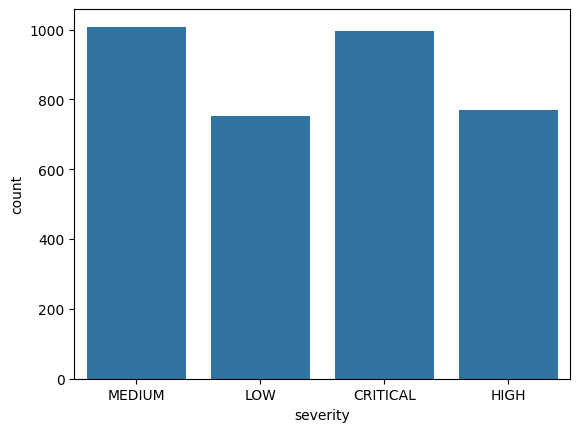

In [835]:
sns.countplot(data=df,x="severity")

In [836]:
gender_map = {
    "m": "MALE",
    "male": "MALE",

    "f": "FEMALE",
    "female": "FEMALE",

    "other": "OTHER",

    "unknown": "UNKNOWN"
}

df["victim_gender"] = (
    df["victim_gender"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(gender_map)
)


df["suspect_gender"] = (
    df["suspect_gender"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(gender_map)
)

<Axes: xlabel='victim_gender', ylabel='count'>

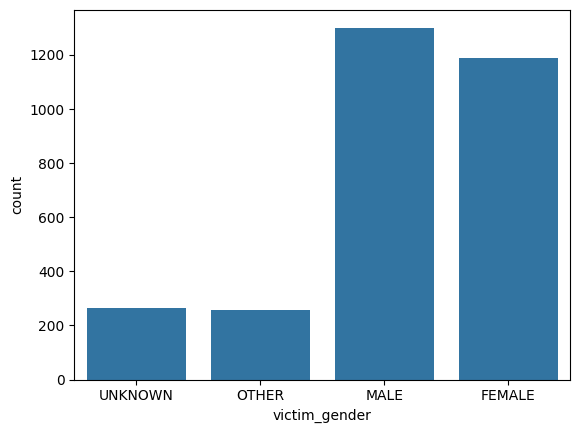

In [837]:
sns.countplot(data=df,x="victim_gender")

<Axes: xlabel='suspect_gender', ylabel='count'>

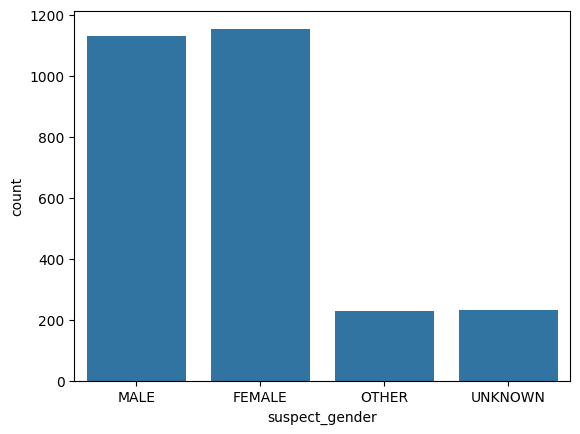

In [838]:
sns.countplot(data=df,x="suspect_gender")

In [839]:
case_status_map = {
    "open": "OPEN",
    "closed": "CLOSED",
    "resolved": "RESOLVED",

    "investgation": "OPEN",
    "under investigation": "OPEN",
    "pendng": "OPEN",
    "pending": "OPEN"
}

df["case_status"] = (
    df["case_status"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(case_status_map)
)

<Axes: xlabel='case_status', ylabel='count'>

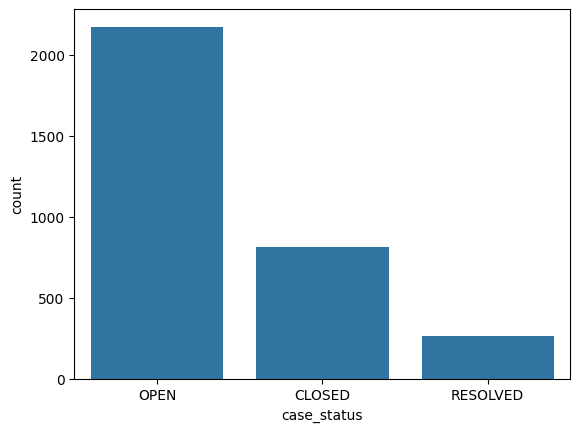

In [840]:
sns.countplot(data=df,x="case_status")

In [841]:
resolution_map = {
    "warning issued": "Warning Issued",
    "warning": "Warning Issued",

    "arrest made": "Arrest Made",
    "arres made": "Arrest Made",

    "dismissed": "Dismissed",
    "case dismissed": "Dismissed",

    "no arrest": "No Arrest"
}

df["resolution"] = (
    df["resolution"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(resolution_map)
)

<Axes: xlabel='resolution', ylabel='count'>

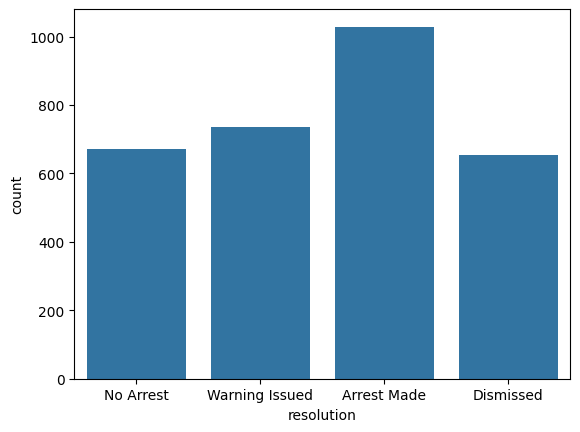

In [842]:
sns.countplot(data=df,x="resolution")

In [843]:
s = df["incident_datetime"].astype("string").str.strip()

parsed = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")

mask1 = s.str.match(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$", na=False)
parsed.loc[mask1] = pd.to_datetime(
    s.loc[mask1],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

mask2 = s.str.match(r"^\d{2}/\d{2}/\d{4} \d{2}:\d{2}$", na=False)
parsed.loc[mask2] = pd.to_datetime(
    s.loc[mask2],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

mask3 = s.str.match(r"^\d{2}-\d{2}-\d{4}$", na=False)
parsed.loc[mask3] = pd.to_datetime(
    s.loc[mask3],
    format="%d-%m-%Y",
    errors="coerce"
)

df["Year"] = parsed.dt.year
df["Month"] = parsed.dt.month

df["Hour"] = (
    parsed.dt.hour
    + parsed.dt.minute / 60
    + parsed.dt.second / 3600
)

In [844]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3792 entries, 0 to 5249
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   incident_id         3792 non-null   object 
 1   crime_type          3792 non-null   object 
 2   district            3792 non-null   object 
 3   city                3792 non-null   object 
 4   state               3792 non-null   object 
 5   address             3792 non-null   object 
 6   latitude            3602 non-null   float64
 7   longitude           3587 non-null   float64
 8   incident_datetime   3541 non-null   object 
 9   officer_id          3792 non-null   object 
 10  officer_first_name  3792 non-null   object 
 11  officer_last_name   3792 non-null   object 
 12  badge_number        3571 non-null   float64
 13  suspect_id          3172 non-null   object 
 14  suspect_first_name  3172 non-null   object 
 15  suspect_last_name   3172 non-null   object 
 16  suspect_age

In [845]:
df["resolution"].value_counts()

,count
resolution,
Arrest Made,1029
Warning Issued,737
No Arrest,671
Dismissed,655


In [846]:
df["case_status"].value_counts()

,count
case_status,
OPEN,2175
CLOSED,816
RESOLVED,265


In [847]:
df["suspect_gender"].value_counts()

,count
suspect_gender,
FEMALE,1155
MALE,1131
UNKNOWN,230
OTHER,229


In [848]:
df["victim_gender"].value_counts()

,count
victim_gender,
MALE,1301
FEMALE,1189
UNKNOWN,264
OTHER,258


In [849]:
df["state"].value_counts()

,count
state,
FL,396
IL,394
NY,392
PA,392
TX,388
AZ,379
NC,375
CA,370
GA,353


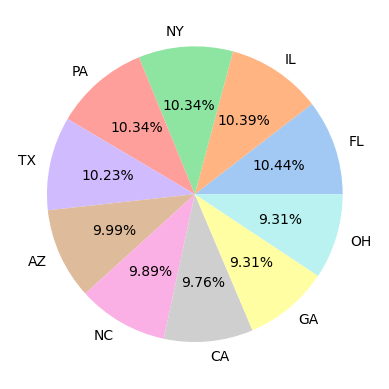

In [850]:
state_counts = df["state"].value_counts()

plt.pie(
    state_counts.values,
    labels=state_counts.index,
    colors=sns.color_palette("pastel"),
    autopct="%.02f%%"
)

plt.show()

In [851]:
df["city"].value_counts()

,count
city,
Riverside,534
Centerville,486
Springfield,480
Oakdale,474
Lakewood,470
Maplewood,462
Hillcrest,457
Fairview,429


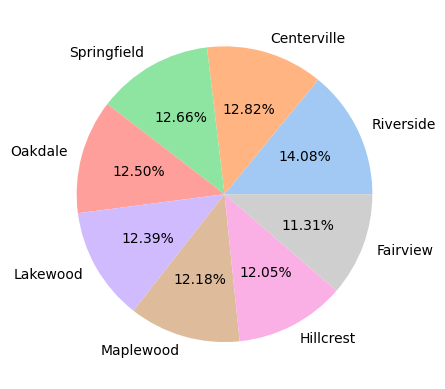

In [852]:
city_counts = df["city"].value_counts()

plt.pie(
    city_counts.values,
    labels=city_counts.index,
    colors=sns.color_palette("pastel"),
    autopct="%.2f%%"
)

plt.show()

<Axes: xlabel='Hour', ylabel='Count'>

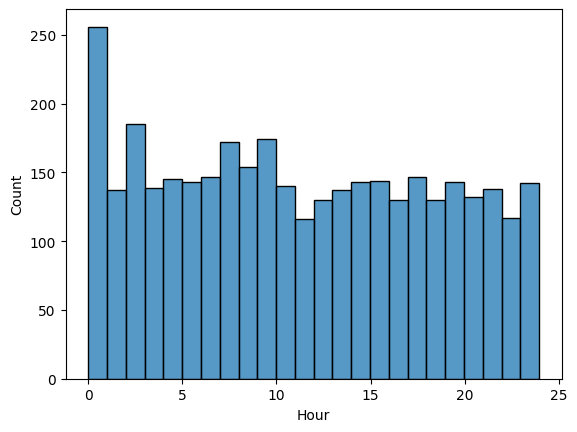

In [853]:
sns.histplot(data=df, x="Hour",bins=24)

<Axes: xlabel='Month', ylabel='count'>

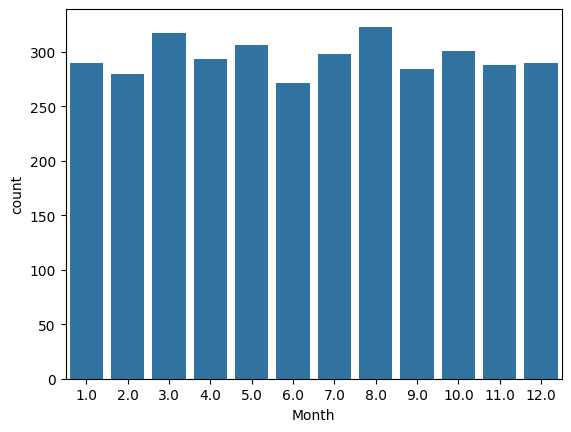

In [854]:
sns.countplot(data=df,x="Month")

<Axes: xlabel='Year', ylabel='count'>

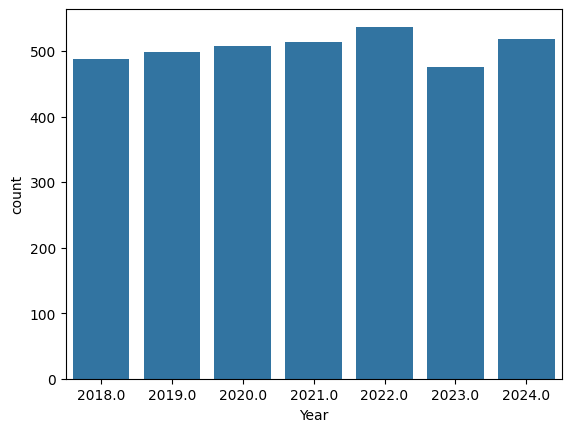

In [855]:
sns.countplot(data=df,x="Year")

In [856]:
pd.set_option("display.max_rows",None)
df["property_loss_usd"].value_counts()


,count
property_loss_usd,
36287.77,2
28548.16,2
8565.75,2
49287.63,2
24392.59,2
16342.44,2
22795.34,2
-6070.81,2
9564.87,2


In [857]:
pd.set_option("display.max_rows",50)

In [858]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3792 entries, 0 to 5249
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   incident_id         3792 non-null   object 
 1   crime_type          3792 non-null   object 
 2   district            3792 non-null   object 
 3   city                3792 non-null   object 
 4   state               3792 non-null   object 
 5   address             3792 non-null   object 
 6   latitude            3602 non-null   float64
 7   longitude           3587 non-null   float64
 8   incident_datetime   3541 non-null   object 
 9   officer_id          3792 non-null   object 
 10  officer_first_name  3792 non-null   object 
 11  officer_last_name   3792 non-null   object 
 12  badge_number        3571 non-null   float64
 13  suspect_id          3172 non-null   object 
 14  suspect_first_name  3172 non-null   object 
 15  suspect_last_name   3172 non-null   object 
 16  suspect_age

In [859]:
df["property_loss_usd"] = pd.to_numeric(df["property_loss_usd"],errors="coerce")
df["property_loss_usd"].isna().sum()

np.int64(402)

In [860]:
df.loc[df["property_loss_usd"] < 0, "property_loss_usd"] = np.nan
df["property_loss_usd"].isna().sum()

np.int64(553)

In [861]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3792 entries, 0 to 5249
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   incident_id         3792 non-null   object 
 1   crime_type          3792 non-null   object 
 2   district            3792 non-null   object 
 3   city                3792 non-null   object 
 4   state               3792 non-null   object 
 5   address             3792 non-null   object 
 6   latitude            3602 non-null   float64
 7   longitude           3587 non-null   float64
 8   incident_datetime   3541 non-null   object 
 9   officer_id          3792 non-null   object 
 10  officer_first_name  3792 non-null   object 
 11  officer_last_name   3792 non-null   object 
 12  badge_number        3571 non-null   float64
 13  suspect_id          3172 non-null   object 
 14  suspect_first_name  3172 non-null   object 
 15  suspect_last_name   3172 non-null   object 
 16  suspect_age

<Axes: ylabel='officer_id'>

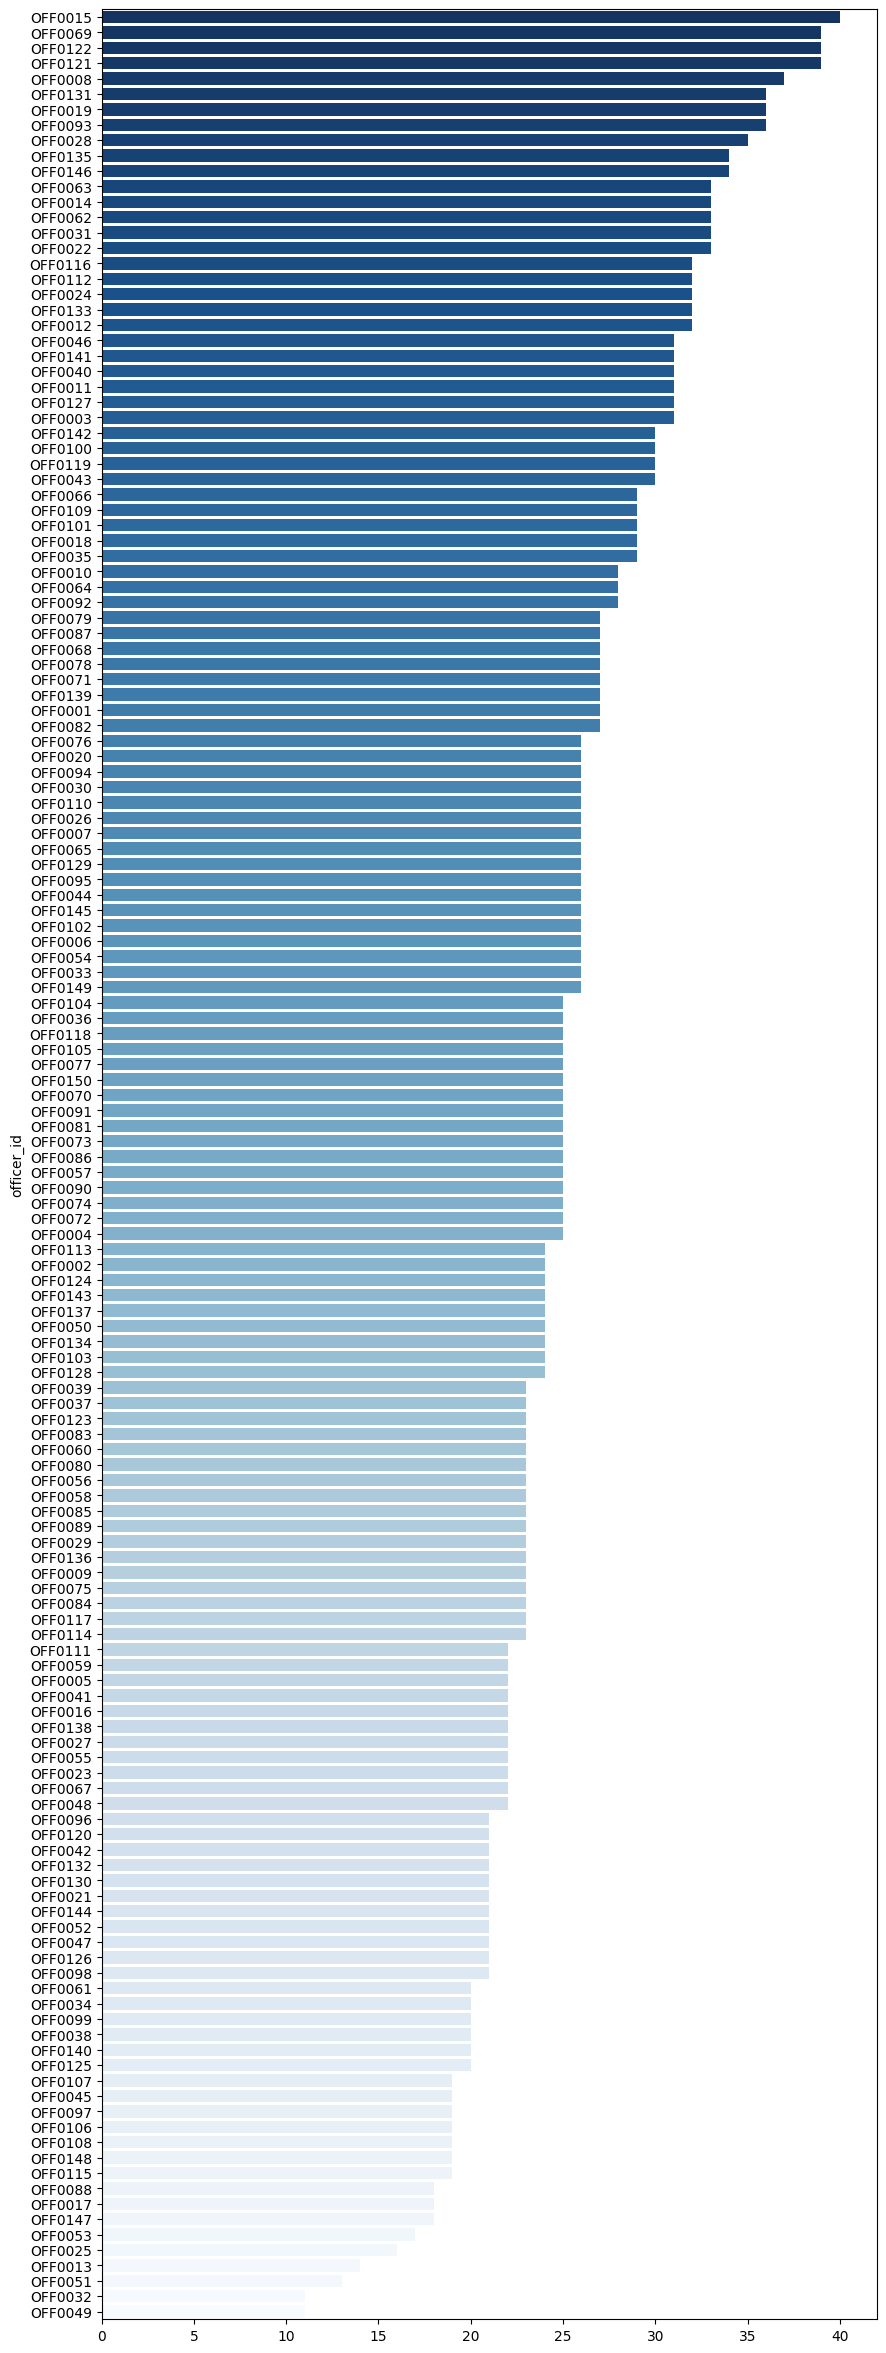

In [862]:
counts = df["officer_id"].value_counts()
plt.figure(figsize=(10,30))
sns.barplot(
    x=counts.values,
    y=counts.index,
    hue = counts.index,
    palette="Blues_r"
)

In [863]:
df.loc[df["num_arrests"] < 0, "num_arrests"] = np.nan
print("Empty Arrests:",df["num_arrests"].isna().sum())
df["num_arrests"].describe()

Empty Arrests: 388


,num_arrests
count,3404.000000
mean,2.448590
std,1.722439
min,0.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,5.000000


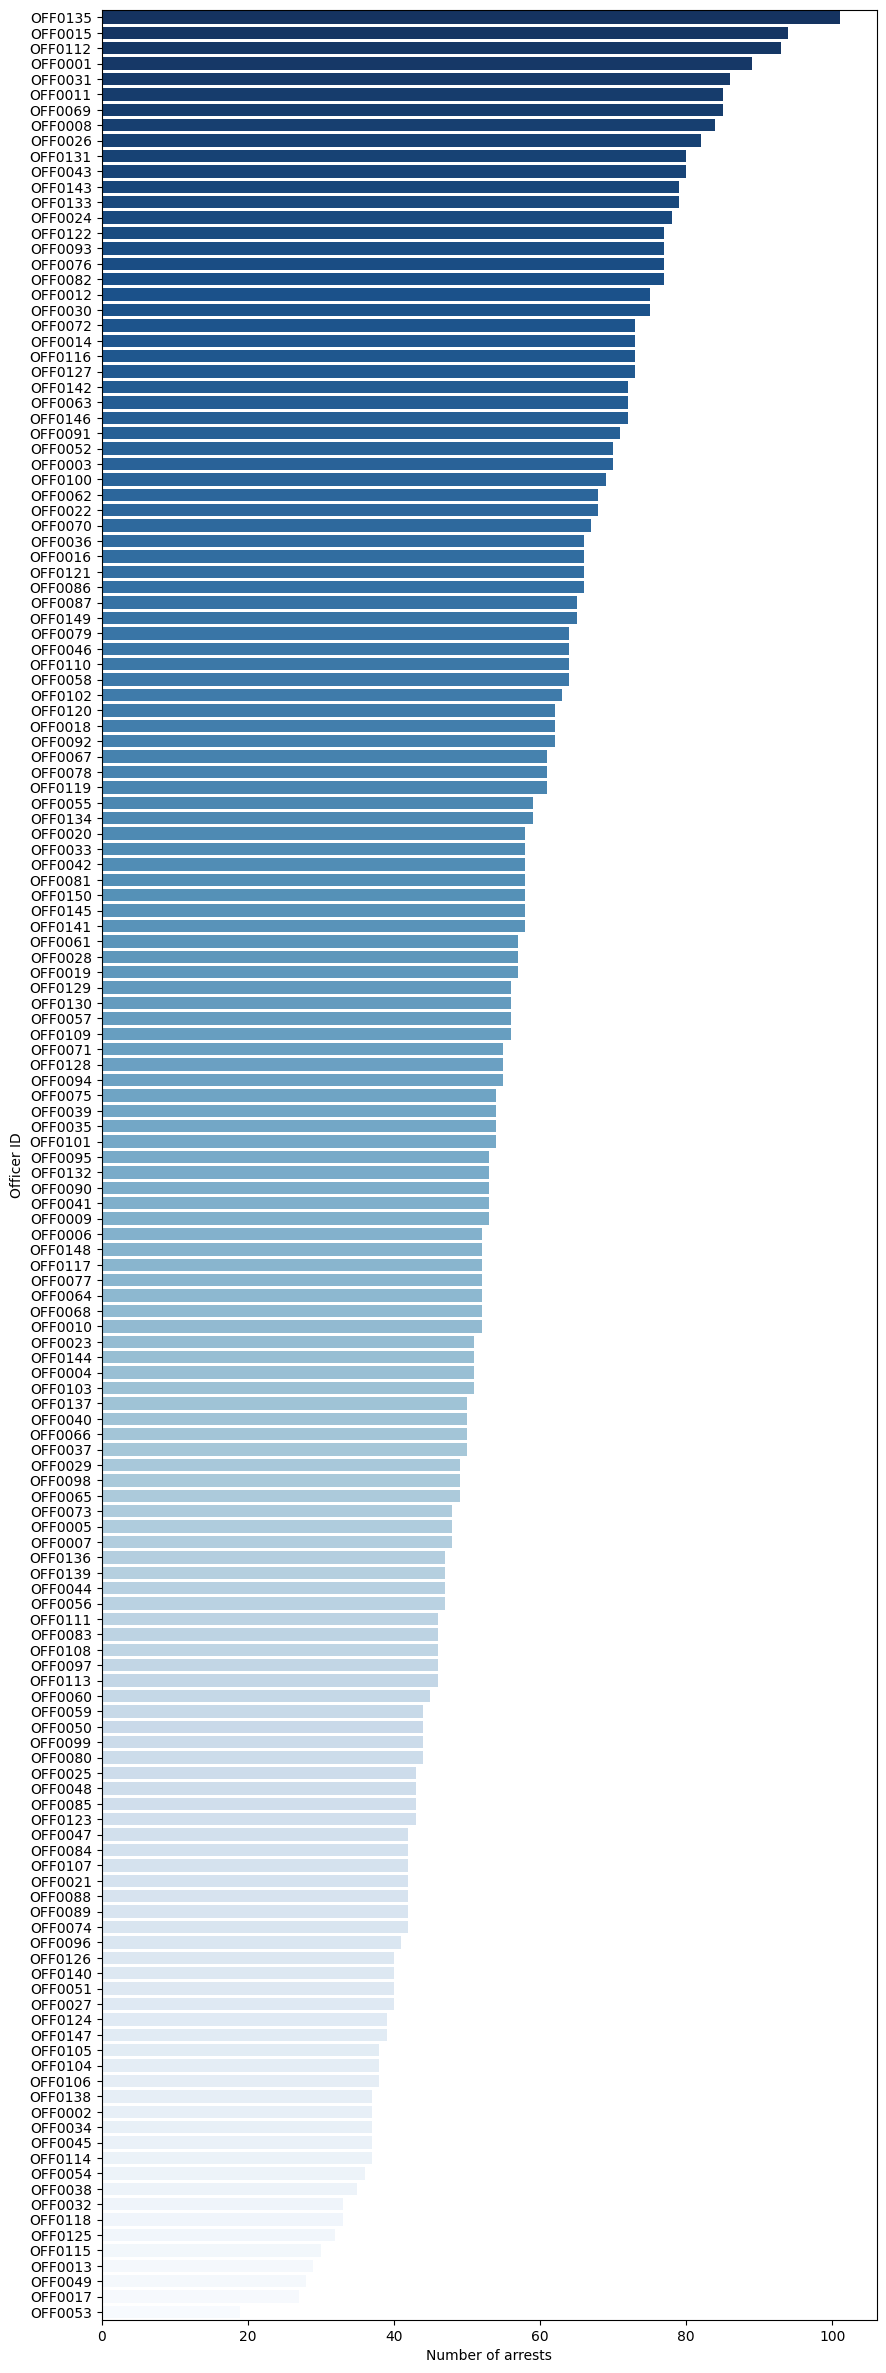

In [864]:
arrests_by_officer = df.groupby("officer_id")["num_arrests"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 30))

sns.barplot(
    x=arrests_by_officer.values,
    y=arrests_by_officer.index,
    hue=arrests_by_officer.index,
    palette="Blues_r"
)

plt.xlabel("Number of arrests")
plt.ylabel("Officer ID")
plt.show()

In [865]:
counts = (
    df.groupby(["crime_type", "officer_id"])
      .size()
      .reset_index(name="count")
)

most_common = (
    counts.loc[
        counts.groupby("crime_type")["count"].idxmax()
    ]
)
print(most_common)

               crime_type officer_id  count
98              Abduction    OFF0121      6
120         Armed Robbery    OFF0003      2
207                 Arson    OFF0071      7
273               Assault    OFF0003      3
381     Assault & Battery    OFF0083      4
398               Battery    OFF0022      2
483   Breaking & Entering    OFF0145      3
569              Burglary    OFF0119      6
597            Cybercrime    OFF0011      6
762                   DUI    OFF0063      7
844     Domestic Violence    OFF0014      5
967          Drug Offense    OFF0015      5
1098                Fraud    OFF0026      8
1225             Homicide    OFF0023      6
1347      Property Damage    OFF0050      3
1455              Robbery    OFF0100      5
1543       Sexual Assault    OFF0054      5
1626                Theft    OFF0009      7
1803          Trespassing    OFF0078      6
1876            Vandalism    OFF0019      4


<Axes: ylabel='resolution'>

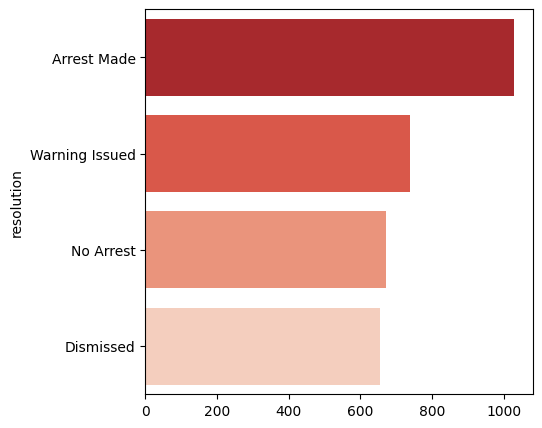

In [866]:
counts = df["resolution"].value_counts()
plt.figure(figsize=(5,5))
sns.barplot(
    x=counts.values,
    y=counts.index,
    hue = counts.index,
    palette="Reds_r"
)

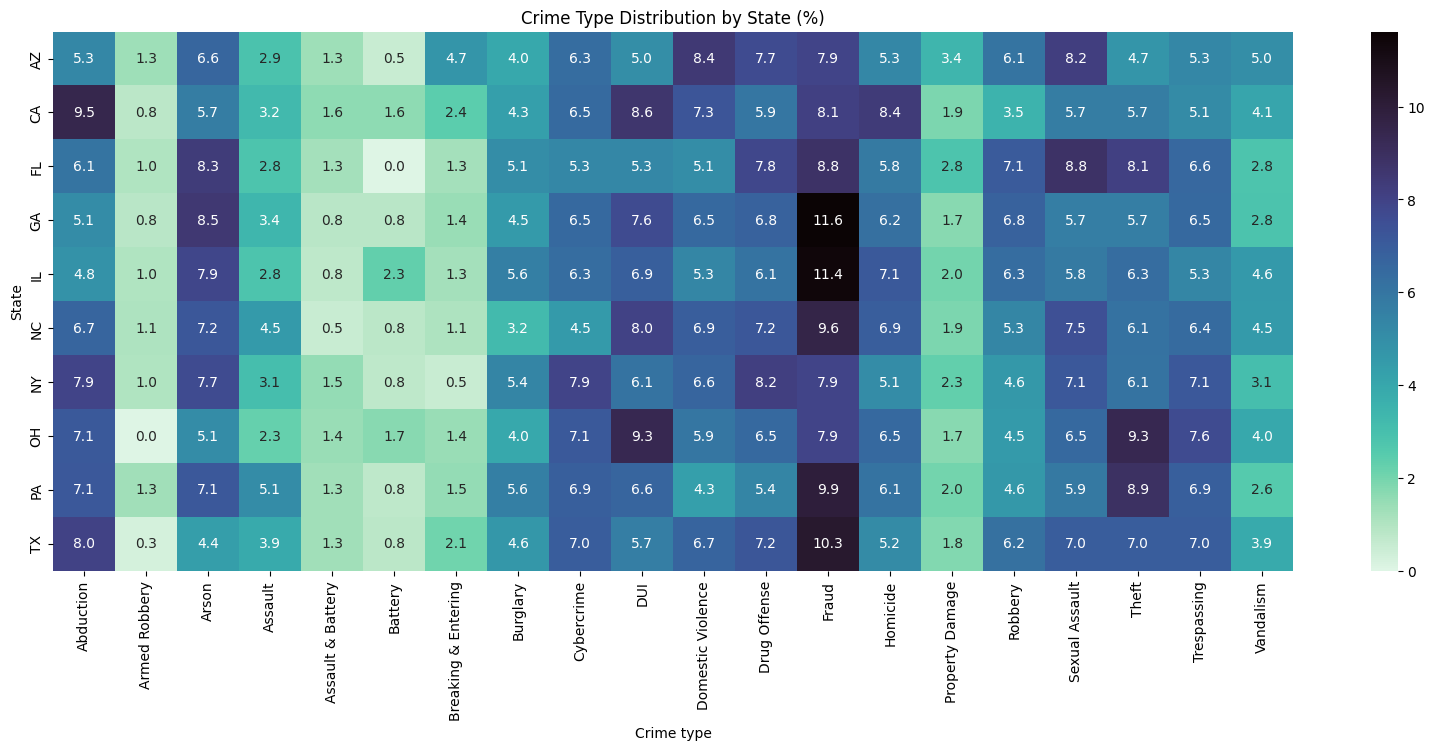

In [867]:
state_distribution = pd.crosstab(
    df["state"],
    df["crime_type"],
    normalize="index"
) * 100

plt.figure(figsize=(20, 7))

sns.heatmap(
    state_distribution,
    annot=True,
    fmt=".1f",
    cmap="mako_r"
)

plt.xlabel("Crime type")
plt.ylabel("State")
plt.title("Crime Type Distribution by State (%)")
plt.show()

In [868]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3792 entries, 0 to 5249
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   incident_id         3792 non-null   object 
 1   crime_type          3792 non-null   object 
 2   district            3792 non-null   object 
 3   city                3792 non-null   object 
 4   state               3792 non-null   object 
 5   address             3792 non-null   object 
 6   latitude            3602 non-null   float64
 7   longitude           3587 non-null   float64
 8   incident_datetime   3541 non-null   object 
 9   officer_id          3792 non-null   object 
 10  officer_first_name  3792 non-null   object 
 11  officer_last_name   3792 non-null   object 
 12  badge_number        3571 non-null   float64
 13  suspect_id          3172 non-null   object 
 14  suspect_first_name  3172 non-null   object 
 15  suspect_last_name   3172 non-null   object 
 16  suspect_age

In [869]:
pd.set_option("display.max_rows",None)
df["district"].value_counts()

,count
district,
Sou,195
Nor,193
SOUTHWEST,75
Northeast,75
NORTH,75
South,74
West,74
North,72
west,71


In [870]:
district_map = {
    "nor": "NORTH",
    "north": "NORTH",

    "sou": "SOUTH",
    "south": "SOUTH",

    "eas": "EAST",
    "east": "EAST",

    "wes": "WEST",
    "west": "WEST",

    "northeast": "NORTHEAST",

    "northwest": "NORTHWEST",

    "southeast": "SOUTHEAST",

    "southwest": "SOUTHWEST",

    "cen": "CENTRAL",
    "central": "CENTRAL",

    "mid": "MIDTOWN",
    "midtown": "MIDTOWN"
}

df["district"] = (
    df["district"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(district_map)
)

In [871]:
df["district"].value_counts()

,count
district,
NORTH,528
SOUTH,511
WEST,401
CENTRAL,395
MIDTOWN,367
EAST,351
SOUTHWEST,332
NORTHEAST,322
NORTHWEST,296


In [874]:
df["district"].isna().sum()

np.int64(0)

In [875]:
df.isna().sum()

,0
incident_id,0
crime_type,0
district,0
city,0
state,0
address,0
latitude,190
longitude,205
incident_datetime,251
officer_id,0


In [876]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3792 entries, 0 to 5249
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   incident_id         3792 non-null   object 
 1   crime_type          3792 non-null   object 
 2   district            3792 non-null   object 
 3   city                3792 non-null   object 
 4   state               3792 non-null   object 
 5   address             3792 non-null   object 
 6   latitude            3602 non-null   float64
 7   longitude           3587 non-null   float64
 8   incident_datetime   3541 non-null   object 
 9   officer_id          3792 non-null   object 
 10  officer_first_name  3792 non-null   object 
 11  officer_last_name   3792 non-null   object 
 12  badge_number        3571 non-null   float64
 13  suspect_id          3172 non-null   object 
 14  suspect_first_name  3172 non-null   object 
 15  suspect_last_name   3172 non-null   object 
 16  suspect_age

In [891]:
df["suspect_missing"] = df["suspect_id"].isna()
print(df.groupby("case_status")["suspect_missing"].mean().sort_values(ascending=False))

case_status
OPEN        0.170575
RESOLVED    0.154717
CLOSED      0.145833
Name: suspect_missing, dtype: float64


Year
2018.0    488
2019.0    499
2020.0    508
2021.0    514
2022.0    537
2023.0    476
2024.0    519
dtype: int64


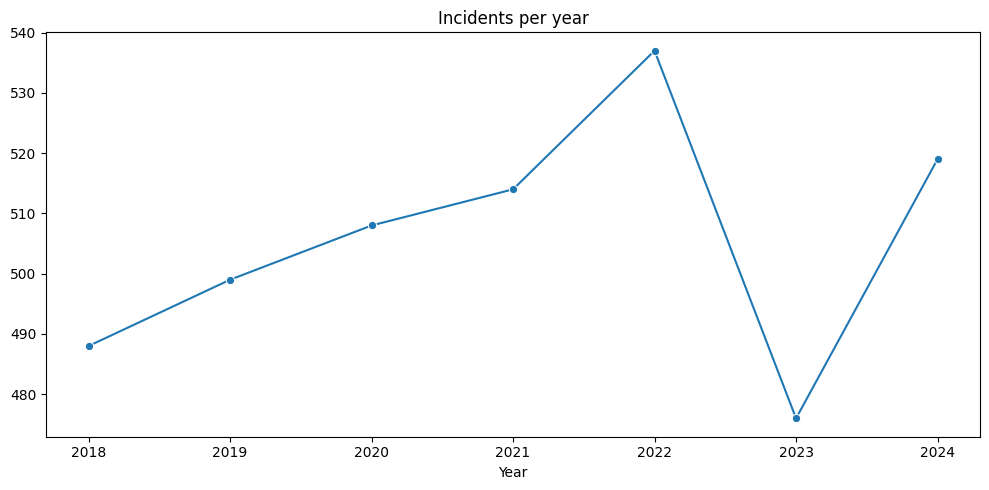

In [890]:
yearly = df.groupby("Year").size()
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly.index, y=yearly.values, marker="o")
plt.title("Incidents per year")
plt.tight_layout()
plt.show()

<Axes: xlabel='severity', ylabel='property_loss_usd'>

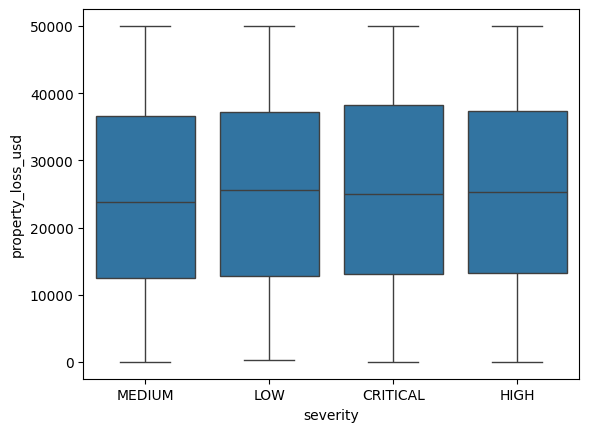

In [892]:
sns.boxplot(data=df,x="severity",y="property_loss_usd")

<Axes: xlabel='Year', ylabel='property_loss_usd'>

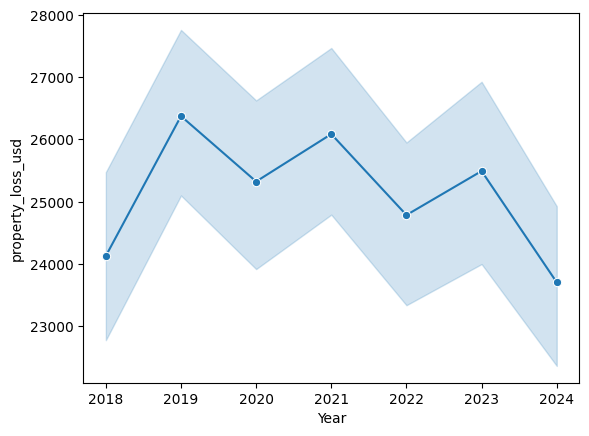

In [896]:
sns.lineplot(data=df,x="Year",y="property_loss_usd",marker="o")

<Axes: xlabel='district', ylabel='count'>

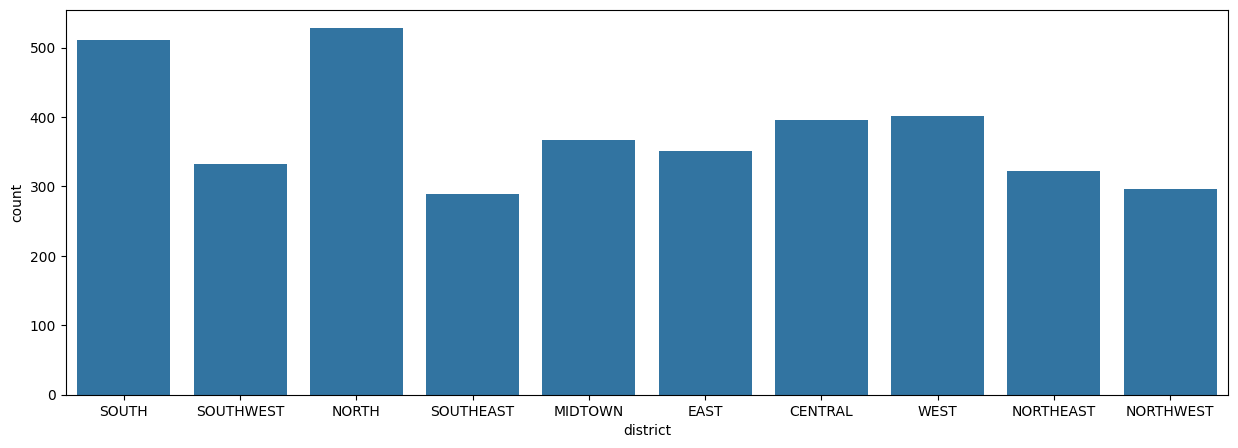

In [902]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x="district")